# Final Deliverable

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---

## Unsupervised Patient Clustering via Diagnosis Code Representations

**Research Question:** Do coarse body-system-level diagnosis features produce clusters as meaningful as fine-grained CCSR category features, and does a hybrid approach offer the best tradeoff between interpretability and granularity?

We evaluate three patient feature representations derived from ICD-10 diagnosis codes:
1. **Body System (coarse baseline)** — ~20 HCUP CCSR body system flags
2. **Full CCSR Categories (fine-grained)** — hundreds of clinical categories, TF-IDF weighted
3. **Hybrid** — body systems concatenated with top-K CCSR categories

Clustering algorithms: **KMeans** and **DBSCAN**. Evaluation: silhouette score, Davies–Bouldin index, ARI stability, and clinical outcome distributions.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Scikit-learn
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer, normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score)
from sklearn.feature_extraction.text import TfidfTransformer

# Scipy sparse matrices
from scipy.sparse import csr_matrix, hstack as sp_hstack

# UMAP
try:
    import umap
    UMAP_AVAILABLE = True
    print('UMAP available.')
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not found — install with: pip install umap-learn')

# HDBSCAN
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
    print('HDBSCAN available.')
except ImportError:
    HDBSCAN_AVAILABLE = False
    print('hdbscan not found — install with: pip install hdbscan')

# ICD Mappings
try:
    from icdmappings import Mapper
    ICD_MAPPER_AVAILABLE = True
    print('icdmappings available.')
except ImportError:
    ICD_MAPPER_AVAILABLE = False
    print('Install icd-mappings: !pip install icd-mappings')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
})
print('Imports complete.')


In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────
# Update the path below to wherever bcs_tx_inpatient.csv is stored.
# On Google Colab with Drive mounted, this would be:
#   /content/drive/MyDrive/<path>/bcs_tx_inpatient.csv
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")

Loaded: 11,174 rows × 169 columns


## 2. Data Preprocessing

We extract all ICD-10 diagnosis codes from each patient encounter, map them to CCSR categories using the [icdmappings](https://pypi.org/project/icd-mappings/) package, and derive the CCSR **body system** as the 3-character prefix of each CCSR code (e.g., `CIR008 → CIR` = *Circulatory system*).

Each patient is then represented as:
- A deduplicated list of **body systems** (coarse)
- A deduplicated list of **CCSR categories** (fine-grained)

In [4]:
# Human-readable names for HCUP CCSR body system codes (v2026.1)
BODY_SYSTEM_NAMES = {
    'MUS': 'Musculoskeletal',
    'CIR': 'Circulatory',
    'RSP': 'Respiratory',
    'NVS': 'Nervous System',
    'DIG': 'Digestive',
    'GNR': 'Genitourinary',
    'END': 'Endocrine/Metabolic',
    'MBD': 'Mental/Behavioral',
    'NEO': 'Neoplasms',
    'INF': 'Infectious/Parasitic',
    'PRG': 'Pregnancy/Childbirth',
    'PNL': 'Perinatal',
    'BLD': 'Blood/Immune',
    'SKN': 'Skin/Subcutaneous',
    'EYE': 'Eye',
    'EAR': 'Ear',
    'INJ': 'Injury/Poisoning',
    'FAC': 'Health Status Factors',
    'SYM': 'Symptoms/Signs',
    'GEN': 'Congenital Anomalies',
    'TBI': 'Traumatic Brain Injury',
}

In [5]:
# ── Build ICD-10 → CCSR mapping ───────────────────────────────────────────────
if not ICD_MAPPER_AVAILABLE:
    raise RuntimeError("icd-mappings package required. Run: pip install icd-mappings")

df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10 codes in dataset: {len(all_codes):,}")

# Batch mapping (icdmappings processes up to ~5 000 codes efficiently)
BATCH_SIZE = 5000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
print(f"CCSR coverage: {mapped:,} / {len(ccsr_mapping):,} "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")

Unique ICD-10 codes in dataset: 5,571
CCSR coverage: 5,571 / 5,571 (100.0%)


In [6]:
# ── Add CCSR and body-system columns ─────────────────────────────────────────
df['PRINC_CCSR']     = df['PRINC_DIAG_CODE'].map(ccsr_mapping)
df['PRINC_BODY_SYS'] = df['PRINC_CCSR'].str[:3]

for i in range(1, 25):
    diag_col = f'OTH_DIAG_CODE_{i}'
    if diag_col not in df.columns:
        continue
    df[f'OTH_CCSR_{i}']     = df[diag_col].map(ccsr_mapping)
    df[f'OTH_BODY_SYS_{i}'] = df[f'OTH_CCSR_{i}'].str[:3]

CCSR_COLS     = [c for c in ['PRINC_CCSR']     + [f'OTH_CCSR_{i}'     for i in range(1, 25)] if c in df.columns]
BODY_SYS_COLS = [c for c in ['PRINC_BODY_SYS'] + [f'OTH_BODY_SYS_{i}' for i in range(1, 25)] if c in df.columns]

def collect_unique(row, cols):
    """Return deduplicated, non-null values from a set of row columns."""
    seen = {}
    for c in cols:
        val = row[c]
        if pd.notna(val):
            seen[val] = None          # dict preserves insertion order
    return list(seen.keys())

df['ccsr_list']     = df.apply(lambda r: collect_unique(r, CCSR_COLS),     axis=1)
df['body_sys_list'] = df.apply(lambda r: collect_unique(r, BODY_SYS_COLS), axis=1)

# Remove patients whose codes are all unmapped (extremely rare)
df = df[df['ccsr_list'].apply(len) > 0].reset_index(drop=True)

print(f"Patients retained: {len(df):,}")
print(f"Avg CCSR codes / patient:     {df['ccsr_list'].apply(len).mean():.2f}")
print(f"Avg body systems / patient:   {df['body_sys_list'].apply(len).mean():.2f}")
print(f"Unique CCSR categories:       {df['ccsr_list'].explode().nunique()}")
print(f"Unique body systems:          {df['body_sys_list'].explode().nunique()}")

# Detect optional clinical outcome columns
LOS_COL    = next((c for c in ['LENGTH_OF_STAY', 'LOS'] if c in df.columns), None)
CHARGE_COL = next((c for c in ['TOTAL_CHARGES', 'CHARGES'] if c in df.columns), None)
print(f"\nLength-of-stay column:  {LOS_COL or 'not found'}")
print(f"Total-charges column:   {CHARGE_COL or 'not found'}")

Patients retained: 11,174
Avg CCSR codes / patient:     10.27
Avg body systems / patient:   5.72
Unique CCSR categories:       439
Unique body systems:          22

Length-of-stay column:  LENGTH_OF_STAY
Total-charges column:   TOTAL_CHARGES


## 3. Feature Engineering

Three patient-level feature matrices are constructed from the per-patient diagnosis lists.

| Representation | Description | Expected dim |
|---|---|---|
| **Body System** | Multi-hot over ~20 CCSR body systems | n × ~20 |
| **Full CCSR** | Multi-hot over all CCSR categories, TF-IDF weighted | n × ~400 (sparse) |
| **Hybrid** | Body systems ‖ top-K CCSR (TF-IDF), concatenated | n × (~20 + K) |

=== Body System Matrix ===
  Shape:                   (11174, 22)
  Sparsity:                74.0%
  Avg systems / patient:   5.72
  Body systems present:    ['BLD', 'CIR', 'DEN', 'DIG', 'EAR', 'END', 'EXT', 'EYE', 'FAC', 'GEN', 'INF', 'INJ', 'MAL', 'MBD', 'MUS', 'NEO', 'NVS', 'PNL', 'PRG', 'RSP', 'SKN', 'SYM']


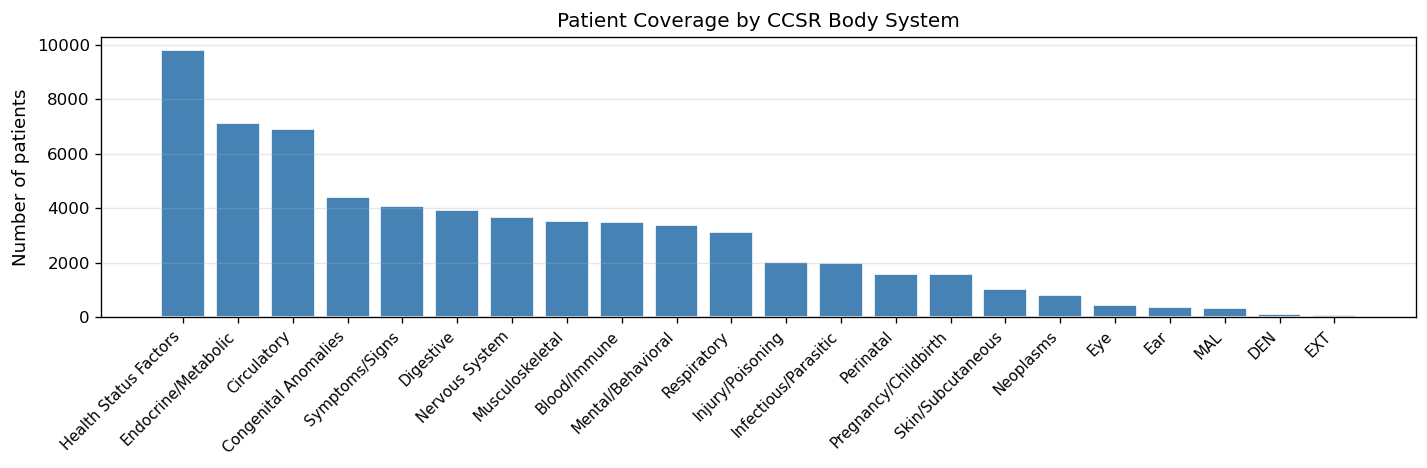

In [7]:
# ── 3.1 Body System Representation (Baseline) ────────────────────────────────
mlb_body = MultiLabelBinarizer(sparse_output=True)
X_body   = mlb_body.fit_transform(df['body_sys_list']).astype(np.float32)
body_labels = mlb_body.classes_

sparsity_body = 1 - X_body.nnz / (X_body.shape[0] * X_body.shape[1])

print("=== Body System Matrix ===")
print(f"  Shape:                   {X_body.shape}")
print(f"  Sparsity:                {sparsity_body * 100:.1f}%")
print(f"  Avg systems / patient:   {X_body.sum(axis=1).mean():.2f}")
print(f"  Body systems present:    {list(body_labels)}")

# Frequency bar chart
sys_freq = np.asarray(X_body.sum(axis=0)).flatten()
sys_names = [BODY_SYSTEM_NAMES.get(s, s) for s in body_labels]

order = np.argsort(sys_freq)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(sys_freq)), sys_freq[order], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(sys_freq)))
ax.set_xticklabels([sys_names[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of patients')
ax.set_title('Patient Coverage by CCSR Body System')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('body_system_freq.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 3.2 Full CCSR Category Representation ────────────────────────────────────
mlb_ccsr   = MultiLabelBinarizer(sparse_output=True)
X_ccsr_raw = mlb_ccsr.fit_transform(df['ccsr_list'])
ccsr_labels = mlb_ccsr.classes_

print(f'Multi-hot CCSR shape (all codes): {X_ccsr_raw.shape}')

# Filter out FAC (Factors influencing health status) codes.
# These are administrative/social codes that dominate clustering but carry
# no specific clinical meaning (e.g. FAC025 = 'encounter for screening').
fac_mask          = np.array([not c.startswith('FAC') for c in ccsr_labels])
n_fac_removed     = (~fac_mask).sum()
X_ccsr_nofac_raw  = X_ccsr_raw[:, fac_mask]
ccsr_nofac_labels = ccsr_labels[fac_mask]
print(f'Removed {n_fac_removed} FAC codes → {fac_mask.sum()} CCSR categories retained')

# TF-IDF: down-weight very common diagnoses (e.g. hypertension in 80%+ of patients)
tfidf  = TfidfTransformer(sublinear_tf=True, norm='l2')
X_ccsr = tfidf.fit_transform(X_ccsr_nofac_raw)

sparsity_ccsr = 1 - X_ccsr.nnz / (X_ccsr.shape[0] * X_ccsr.shape[1])
print(f'TF-IDF CCSR shape (FAC-filtered): {X_ccsr.shape}')
print(f'Sparsity:                         {sparsity_ccsr * 100:.1f}%')

# Top-20 CCSR categories by raw frequency (non-FAC)
ccsr_freq_raw = np.asarray(X_ccsr_nofac_raw.sum(axis=0)).flatten()
top20_idx     = np.argsort(ccsr_freq_raw)[::-1][:20]
print('\nTop-20 CCSR categories by frequency (FAC removed):')
for rank, i in enumerate(top20_idx, 1):
    print(f'  {rank:2d}. {ccsr_nofac_labels[i]}: {int(ccsr_freq_raw[i]):,} patients')


In [ ]:
# ── 3.3 Hybrid Representation ────────────────────────────────────────
TOP_K = 200   # number of most-frequent CCSR categories to include

# Select top-K from FAC-filtered CCSR categories by raw patient frequency
ccsr_freq_arr     = np.asarray(X_ccsr_nofac_raw.sum(axis=0)).flatten()
topk_idx          = np.argsort(ccsr_freq_arr)[::-1][:TOP_K]
topk_labels       = ccsr_nofac_labels[topk_idx]

X_ccsr_topk       = X_ccsr_nofac_raw[:, topk_idx]
tfidf_topk        = TfidfTransformer(sublinear_tf=True, norm='l2')
X_ccsr_topk_tfidf = tfidf_topk.fit_transform(X_ccsr_topk)

# Concatenate body-system (float) with top-K CCSR (TF-IDF)
X_hybrid = sp_hstack([X_body, X_ccsr_topk_tfidf], format='csr')

print('=== Hybrid Representation ===')
print(f'  Body system features:   {X_body.shape[1]}')
print(f'  Top-K CCSR features:    {X_ccsr_topk_tfidf.shape[1]}  (K={TOP_K}, FAC-filtered)')
print(f'  Combined shape:         {X_hybrid.shape}')
print(f'  Top-K CCSR labels:      {list(topk_labels[:10])} ...')


## 4. Dimensionality Reduction

Two reduction strategies are used depending on the representation:

- **Body System** (22 binary features): Truncated SVD retaining ≥90% variance, followed by StandardScaler. Euclidean distance is appropriate here.
- **Full CCSR & Hybrid** (sparse TF-IDF): UMAP with `metric='cosine'` and `n_components=20`. Cosine metric is correct for TF-IDF vectors; UMAP preserves local neighborhood structure far better than SVD on highly sparse inputs. Falls back to TruncatedSVD if `umap-learn` is not installed.

A separate 2D UMAP embedding (from the reduced inputs) is computed for visualization only.


In [ ]:
# ── 4.1 Truncated SVD for Body System ─────────────────────────────────────
def reduce_svd(X_sparse, n_components=50, variance_threshold=0.90, name=''):
    n_comp = min(n_components, min(X_sparse.shape) - 1)
    svd    = TruncatedSVD(n_components=n_comp, random_state=RANDOM_SEED)
    X_red  = svd.fit_transform(X_sparse)
    cumvar = svd.explained_variance_ratio_.cumsum()
    n_keep = int(np.searchsorted(cumvar, variance_threshold)) + 1
    n_keep = min(n_keep, n_comp)
    print(f'[{name}] {X_sparse.shape} → SVD({n_keep}) — '
          f'{cumvar[n_keep-1]*100:.1f}% variance retained')
    return X_red[:, :n_keep], svd

# ── 4.2 UMAP for sparse TF-IDF representations ─────────────────────────────
def reduce_umap(X, n_components=20, metric='cosine', name=''):
    """
    UMAP reduction for clustering (n_components > 2).
    Uses cosine metric, which is appropriate for TF-IDF vectors.
    Falls back to TruncatedSVD if umap-learn is not installed.
    """
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=n_components, metric=metric,
                            n_neighbors=30, min_dist=0.0,
                            random_state=RANDOM_SEED)
        X_red = reducer.fit_transform(X)
        print(f'[{name}] UMAP({n_components}, metric={metric}) — shape: {X_red.shape}')
        return X_red, reducer
    else:
        print(f'[{name}] UMAP unavailable — falling back to TruncatedSVD')
        X_red, svd = reduce_svd(X, n_components=n_components,
                                variance_threshold=0.90, name=name)
        return X_red, svd

print('=== Dimensionality Reduction ===')

# Body system: SVD (22 features, Euclidean fine)
X_body_svd, svd_body = reduce_svd(X_body.astype(float), n_components=50,
                                   variance_threshold=0.90, name='Body System')
scaler_body = StandardScaler()
X_body_pca  = scaler_body.fit_transform(X_body_svd)

# Full CCSR: UMAP cosine (sparse TF-IDF)
X_ccsr_umap, umap_ccsr   = reduce_umap(X_ccsr, n_components=20,
                                        metric='cosine', name='Full CCSR  ')

# Hybrid: UMAP cosine (sparse TF-IDF + body)
X_hybrid_umap, umap_hybrid = reduce_umap(X_hybrid, n_components=20,
                                          metric='cosine', name='Hybrid     ')

print('\nReduced matrices ready for clustering.')
print(f'  Body System:  {X_body_pca.shape}   (SVD + StandardScaler)')
print(f'  Full CCSR:    {X_ccsr_umap.shape}   (UMAP cosine)')
print(f'  Hybrid:       {X_hybrid_umap.shape}   (UMAP cosine)')


In [ ]:
# ── 4.3 2D Embedding for Visualization ──────────────────────────────────────
def embed_2d(X, metric='euclidean', name=''):
    """UMAP 2D preferred; fall back to t-SNE if umap-learn unavailable."""
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, n_neighbors=30,
                            min_dist=0.1, metric=metric,
                            random_state=RANDOM_SEED)
        method_label = 'UMAP'
    else:
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, perplexity=40,
                       n_iter=1000, random_state=RANDOM_SEED)
        method_label = 't-SNE'
    X_2d = reducer.fit_transform(X)
    print(f'[{name}] 2D {method_label} complete — shape: {X_2d.shape}')
    return X_2d, method_label

# Use the already-reduced data as input (faster & cleaner than raw sparse)
print('Computing 2D embeddings for visualization ...')
X_body_2d,   EMBED_LABEL = embed_2d(X_body_pca,    metric='euclidean', name='Body System')
X_ccsr_2d,   _           = embed_2d(X_ccsr_umap,   metric='euclidean', name='Full CCSR  ')
X_hybrid_2d, _           = embed_2d(X_hybrid_umap, metric='euclidean', name='Hybrid     ')
print(f'\nEmbedding method: {EMBED_LABEL}')


## 5. Clustering

Three complementary algorithms are applied to each representation:

- **KMeans** — partition-based; best K (3–20) selected by silhouette score on L2-normalized input.
- **HDBSCAN** — hierarchical density-based; no eps parameter; automatically finds clusters of varying density and marks low-density points as noise. `min_cluster_size` is tuned over {50, 80, 120}.
- **Agglomerative (Ward)** — hierarchical linkage; Ward minimizes within-cluster variance at each merge step, producing compact, roughly equal-sized clusters. K is set to the best K from KMeans for a fair comparison.


In [ ]:
# ── 5.1 KMeans ────────────────────────────────────────────────────────────────────
def best_kmeans(X, k_range=range(3, 21), name=''):
    """
    Fit KMeans for each K in k_range on L2-normalized input.
    Return labels and best K (highest silhouette score).
    """
    X_norm = normalize(X)   # unit-norm rows; makes Euclidean ≈ cosine distance
    scores, models = {}, {}
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_SEED,
                        n_init=15, max_iter=500)
        labels = km.fit_predict(X_norm)
        if len(set(labels)) < 2:
            continue
        sil = silhouette_score(X_norm, labels,
                               sample_size=min(2000, len(X_norm)),
                               random_state=RANDOM_SEED)
        scores[k], models[k] = sil, labels

    best_k = max(scores, key=scores.get)
    print(f'[{name}] Best K = {best_k} | Silhouette = {scores[best_k]:.4f}')
    for k in sorted(scores):
        marker = ' ◄' if k == best_k else ''
        print(f'  K={k}: silhouette={scores[k]:.4f}{marker}')
    return models[best_k], best_k

print('=== KMeans Clustering (K = 3–20, L2-normalized input) ===\n')
lbl_km_body,   K_body   = best_kmeans(X_body_pca,    name='Body System')
lbl_km_ccsr,   K_ccsr   = best_kmeans(X_ccsr_umap,   name='Full CCSR  ')
lbl_km_hybrid, K_hybrid = best_kmeans(X_hybrid_umap, name='Hybrid     ')


In [ ]:
# ── 5.2 HDBSCAN ────────────────────────────────────────────────────────────────
def best_hdbscan(X, min_sizes=(50, 80, 120), name=''):
    """
    Try several min_cluster_size values; keep the result with the best
    silhouette score on non-noise points.
    """
    if not HDBSCAN_AVAILABLE:
        print(f'[{name}] HDBSCAN unavailable — skipping.')
        return np.zeros(len(X), dtype=int), 1

    best_sil, best_lbl = -np.inf, None
    for mcs in min_sizes:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=10,
                                     cluster_selection_method='eom')
        labels = clusterer.fit_predict(X)
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        noise  = (labels == -1).mean() * 100
        if n_cl < 2:
            print(f'  [{name}] mcs={mcs}: {n_cl} cluster(s), {noise:.1f}% noise — skipped')
            continue
        mask = labels != -1
        sil  = silhouette_score(X[mask], labels[mask],
                                sample_size=min(2000, mask.sum()),
                                random_state=RANDOM_SEED)
        print(f'  [{name}] mcs={mcs}: {n_cl} clusters, {noise:.1f}% noise, sil={sil:.4f}')
        if sil > best_sil:
            best_sil, best_lbl = sil, labels

    if best_lbl is None:
        print(f'[{name}] No valid HDBSCAN solution found.')
        return np.full(len(X), -1), 0

    n_cl  = len(set(best_lbl)) - (1 if -1 in best_lbl else 0)
    noise = (best_lbl == -1).mean() * 100
    print(f'[{name}] Best HDBSCAN → {n_cl} clusters, {noise:.1f}% noise, sil={best_sil:.4f}')
    return best_lbl, n_cl

print('=== HDBSCAN Clustering ===\n')
lbl_hdb_body,   K_hdb_body   = best_hdbscan(X_body_pca,    name='Body System')
lbl_hdb_ccsr,   K_hdb_ccsr   = best_hdbscan(X_ccsr_umap,   name='Full CCSR  ')
lbl_hdb_hybrid, K_hdb_hybrid = best_hdbscan(X_hybrid_umap, name='Hybrid     ')

# ── 5.3 Agglomerative Clustering (Ward linkage) ───────────────────────────────
def run_agglomerative(X, k, name=''):
    """Ward-linkage hierarchical clustering — minimises within-cluster variance."""
    agg    = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)
    sil    = silhouette_score(X, labels,
                              sample_size=min(2000, len(X)),
                              random_state=RANDOM_SEED)
    print(f'[{name}] Agglomerative K={k} | Silhouette = {sil:.4f}')
    return labels

print('\n=== Agglomerative Clustering (Ward, K = best KMeans K) ===\n')
lbl_agg_body   = run_agglomerative(X_body_pca,    K_body,   name='Body System')
lbl_agg_ccsr   = run_agglomerative(X_ccsr_umap,   K_ccsr,   name='Full CCSR  ')
lbl_agg_hybrid = run_agglomerative(X_hybrid_umap, K_hybrid, name='Hybrid     ')


## 6. Evaluation

We report **silhouette score** (higher = more compact, well-separated clusters; max 1.0) and **Davies–Bouldin index** (lower = better; min 0.0) for all three representations × three algorithm combinations.

For HDBSCAN results, noise points (label = −1) are excluded before computing metrics.


In [ ]:
# ── 6.1 Quantitative Evaluation ────────────────────────────────────────────────
def evaluate_clustering(X, labels, rep_name, method):
    """Compute silhouette and Davies-Bouldin scores, excluding noise (label=-1)."""
    mask    = labels != -1
    n_cl    = len(set(labels[mask]))
    noise_p = (~mask).mean() * 100

    if n_cl < 2 or mask.sum() < 2:
        return dict(Representation=rep_name, Method=method,
                    N_Clusters=n_cl, Silhouette=np.nan,
                    Davies_Bouldin=np.nan, Noise_Pct=round(noise_p, 1))

    X_cl, l_cl = X[mask], labels[mask]
    sil = silhouette_score(X_cl, l_cl,
                           sample_size=min(2000, len(X_cl)),
                           random_state=RANDOM_SEED)
    db  = davies_bouldin_score(X_cl, l_cl)
    return dict(Representation=rep_name, Method=method,
                N_Clusters=n_cl,
                Silhouette=round(sil, 4),
                Davies_Bouldin=round(db, 4),
                Noise_Pct=round(noise_p, 1))

rows = []
for X_red, km_lbl, hdb_lbl, agg_lbl, rep in [
    (X_body_pca,    lbl_km_body,   lbl_hdb_body,   lbl_agg_body,   'Body System'),
    (X_ccsr_umap,   lbl_km_ccsr,   lbl_hdb_ccsr,   lbl_agg_ccsr,   'Full CCSR  '),
    (X_hybrid_umap, lbl_km_hybrid, lbl_hdb_hybrid, lbl_agg_hybrid, 'Hybrid     '),
]:
    rows.append(evaluate_clustering(X_red, km_lbl,  rep, 'KMeans'))
    rows.append(evaluate_clustering(X_red, hdb_lbl, rep, 'HDBSCAN'))
    rows.append(evaluate_clustering(X_red, agg_lbl, rep, 'Agglomerative'))

metrics_df = pd.DataFrame(rows)
metrics_df['Representation'] = metrics_df['Representation'].str.strip()
metrics_df['Method']         = metrics_df['Method'].str.strip()
print('=== Clustering Evaluation Metrics ===')
print(metrics_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
methods   = ['KMeans', 'HDBSCAN', 'Agglomerative']
reps      = ['Body System', 'Full CCSR', 'Hybrid']
x         = np.arange(len(reps))
width     = 0.25
colors    = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric, ylabel, better in [
    (axes[0], 'Silhouette',     'Silhouette Score (higher = better)', 'high'),
    (axes[1], 'Davies_Bouldin', 'Davies-Bouldin Index (lower = better)', 'low'),
]:
    for i, (method, color) in enumerate(zip(methods, colors)):
        vals = [metrics_df.loc[(metrics_df.Representation == r) &
                               (metrics_df.Method == method), metric].values
                for r in reps]
        vals = [v[0] if len(v) else np.nan for v in vals]
        ax.bar(x + i * width, vals, width, label=method, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(reps)
    ax.set_ylabel(ylabel)
    ax.set_title(metric.replace('_', ' '))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Clustering Evaluation: All Methods', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 6.2 Clinical Outcome Distributions per Cluster ────────────────────────────
outcome_cols = [(LOS_COL, 'Length of Stay (days)'),
                (CHARGE_COL, 'Total Charges ($)')]
outcome_cols = [(c, lbl) for c, lbl in outcome_cols if c is not None]

clustering_configs = [
    ('Body System\nKMeans',         lbl_km_body,   K_body),
    ('Body System\nAgglomerative',  lbl_agg_body,  K_body),
    ('Full CCSR\nKMeans',           lbl_km_ccsr,   K_ccsr),
    ('Full CCSR\nAgglomerative',    lbl_agg_ccsr,  K_ccsr),
    ('Hybrid\nKMeans',              lbl_km_hybrid, K_hybrid),
    ('Hybrid\nAgglomerative',       lbl_agg_hybrid, K_hybrid),
]

if outcome_cols:
    for col, ylabel in outcome_cols:
        fig, axes = plt.subplots(2, 3, figsize=(18, 9), squeeze=False)
        for ax, (title, lbl, k) in zip(axes.flat, clustering_configs):
            tmp = df.copy()
            tmp['cluster'] = lbl
            tmp = tmp[tmp['cluster'] != -1].copy()
            tmp['cluster'] = tmp['cluster'].astype(str)
            tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
            palette = sns.color_palette('husl', tmp['cluster'].nunique())
            sns.boxplot(data=tmp, x='cluster', y=col, ax=ax,
                        palette=palette, showfliers=False, linewidth=1.2)
            ax.set_xlabel('Cluster')
            ax.set_ylabel(ylabel)
            ax.set_title(title, fontsize=10)
            ax.grid(axis='y', alpha=0.3)
            ax.tick_params(axis='x', labelsize=8)
        plt.suptitle(f'{ylabel} by Cluster\n(Row 1: KMeans  |  Row 2: Agglomerative)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'clinical_outcomes_{col}.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('LENGTH_OF_STAY and TOTAL_CHARGES not found — skipping clinical outcome plots.')
    print('Add them to `df` if available in the source data.')


## 7. Cluster Interpretation

For each cluster we report the **most common body systems** and **CCSR categories**, together with demographic and clinical summaries where available. This allows us to assign a clinically meaningful label to each cluster.

In [ ]:
# ── 7. Cluster Interpretation ──────────────────────────────────────────────────
def interpret_clusters(df, labels, name='', top_n=5):
    df_tmp = df.copy()
    df_tmp['cluster'] = labels

    print(f"\n{'='*65}")
    print(f'  {name}')
    print(f"{'='*65}")

    for cid in sorted(set(labels)):
        if cid == -1:
            noise_n = (labels == -1).sum()
            print(f'\n  Noise (n={noise_n:,}, {noise_n/len(labels)*100:.1f}%) — low-density points not assigned to any cluster')
            continue
        sub = df_tmp[df_tmp['cluster'] == cid]
        n   = len(sub)
        pct = n / len(df_tmp) * 100

        all_sys  = [s for lst in sub['body_sys_list'] for s in lst]
        all_ccsr = [c for lst in sub['ccsr_list']     for c in lst]
        top_sys  = Counter(all_sys).most_common(top_n)
        top_ccsr = Counter(all_ccsr).most_common(top_n)

        extras = []
        if 'PAT_AGE' in df_tmp.columns:
            age = pd.to_numeric(sub['PAT_AGE'], errors='coerce').median()
            if pd.notna(age): extras.append(f'Median age={age:.0f}')
        if LOS_COL and LOS_COL in df_tmp.columns:
            los = pd.to_numeric(sub[LOS_COL], errors='coerce').median()
            if pd.notna(los): extras.append(f'Median LOS={los:.1f}d')
        if CHARGE_COL and CHARGE_COL in df_tmp.columns:
            chg = pd.to_numeric(sub[CHARGE_COL], errors='coerce').median()
            if pd.notna(chg): extras.append(f'Median charges=${chg:,.0f}')

        extra_str = ('  |  ' + ', '.join(extras)) if extras else ''
        print(f'\n  Cluster {cid}  (n={n:,}, {pct:.1f}%){extra_str}')
        print(f'    Top body systems:')
        for code, cnt in top_sys:
            print(f'      {code:4s}  {BODY_SYSTEM_NAMES.get(code, code):25s}  '
                  f'{cnt:5,}  ({cnt/n*100:.1f}%)')
        print(f'    Top CCSR categories:')
        for code, cnt in top_ccsr:
            print(f'      {code:8s}  {cnt:5,}  ({cnt/n*100:.1f}%)')


for lbl, name in [
    (lbl_km_body,    f'Body System — KMeans  K={K_body}'),
    (lbl_agg_body,   f'Body System — Agglomerative  K={K_body}'),
    (lbl_hdb_body,   f'Body System — HDBSCAN  K={K_hdb_body}'),
    (lbl_km_ccsr,    f'Full CCSR   — KMeans  K={K_ccsr}'),
    (lbl_agg_ccsr,   f'Full CCSR   — Agglomerative  K={K_ccsr}'),
    (lbl_hdb_ccsr,   f'Full CCSR   — HDBSCAN  K={K_hdb_ccsr}'),
    (lbl_km_hybrid,  f'Hybrid      — KMeans  K={K_hybrid}'),
    (lbl_agg_hybrid, f'Hybrid      — Agglomerative  K={K_hybrid}'),
    (lbl_hdb_hybrid, f'Hybrid      — HDBSCAN  K={K_hdb_hybrid}'),
]:
    interpret_clusters(df, lbl, name=name)


## 8. Stability Analysis

We assess how robust each clustering solution is by subsampling 80% of the data five times, re-running KMeans with the selected K, and computing the **Adjusted Rand Index (ARI)** between consecutive subsample runs. ARI = 1.0 means perfect agreement; ARI < 0.5 suggests the solution is highly sensitive to the sample.

In [ ]:
# ── 8. Stability Analysis ──────────────────────────────────────────────────────
def stability_ari(X, best_k, n_trials=5, subsample_frac=0.80,
                  name='', method='kmeans'):
    """
    Run clustering n_trials times on independent 80% subsamples.
    Compute ARI between consecutive subsample pairs on shared indices.
    Supports 'kmeans' and 'agglomerative'.
    """
    n     = X.shape[0]
    n_sub = int(n * subsample_frac)
    maps  = []

    for t in range(n_trials):
        rng   = np.random.RandomState(RANDOM_SEED + t)
        idx   = rng.choice(n, size=n_sub, replace=False)
        X_sub = X[idx]

        if method == 'kmeans':
            X_norm = normalize(X_sub)
            clf    = KMeans(n_clusters=best_k, random_state=RANDOM_SEED + t,
                            n_init=10, max_iter=300)
            clf.fit(X_norm)
            labels = clf.labels_
        elif method == 'agglomerative':
            clf    = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
            labels = clf.fit_predict(X_sub)
        else:
            raise ValueError(f'Unknown method: {method}')

        maps.append(dict(zip(idx.tolist(), labels.tolist())))

    ari_scores = []
    for m1, m2 in zip(maps[:-1], maps[1:]):
        common = list(set(m1.keys()) & set(m2.keys()))
        if len(common) < 10:
            continue
        l1 = [m1[i] for i in common]
        l2 = [m2[i] for i in common]
        ari_scores.append(adjusted_rand_score(l1, l2))

    mean_ari = np.mean(ari_scores) if ari_scores else float('nan')
    std_ari  = np.std(ari_scores)  if ari_scores else float('nan')
    print(f'[{name}]  K={best_k}  ARI = {mean_ari:.4f} ± {std_ari:.4f}  '
          f'(n_trials={n_trials}, subsample={int(subsample_frac*100)}%)')
    return mean_ari, std_ari

print('=== Stability Analysis (80% Subsampling, 5 Trials) ===\n')

stability_results = {}
for X_red, k, rep in [
    (X_body_pca,    K_body,   'Body System'),
    (X_ccsr_umap,   K_ccsr,   'Full CCSR  '),
    (X_hybrid_umap, K_hybrid, 'Hybrid     '),
]:
    for method in ['kmeans', 'agglomerative']:
        name_lbl = f"{rep.strip()} — {method.capitalize()}"
        mean, std = stability_ari(X_red, k, name=name_lbl, method=method)
        stability_results[(rep.strip(), method)] = (mean, std)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
reps    = ['Body System', 'Full CCSR', 'Hybrid']
methods = ['kmeans', 'agglomerative']
colors  = ['steelblue', 'mediumseagreen']
x       = np.arange(len(reps))
width   = 0.35

for i, (method, color) in enumerate(zip(methods, colors)):
    means = [stability_results.get((r, method), (np.nan, np.nan))[0] for r in reps]
    stds  = [stability_results.get((r, method), (np.nan, np.nan))[1] for r in reps]
    ax.bar(x + i * width, means, width, yerr=stds, capsize=4,
           label=method.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(reps)
ax.set_ylabel('Mean ARI (higher = more stable)')
ax.set_title('Clustering Stability (80% Subsample, 5 Trials)', fontsize=12)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='ARI = 0.5 threshold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('stability_ari.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Visualization

Side-by-side 2D scatter plots (UMAP or t-SNE) for all three representations under all three algorithms. Each point is one patient encounter; colors denote cluster assignment (grey = HDBSCAN noise).


In [ ]:
# ── 9. Cluster Scatter Plots ──────────────────────────────────────────────────
def cluster_scatter(ax, X_2d, labels, title, embed_label):
    """2D scatter colored by cluster assignment."""
    unique = sorted(set(labels))
    n_cl   = max(len([c for c in unique if c != -1]), 10)
    cmap   = plt.cm.get_cmap('tab10', n_cl)

    for cid in unique:
        mask  = labels == cid
        color = '#aaaaaa' if cid == -1 else cmap(cid % n_cl)
        lbl   = 'Noise' if cid == -1 else f'C{cid} (n={mask.sum():,})'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], s=5, alpha=0.40, label=lbl, rasterized=True)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'{embed_label} 1', fontsize=8)
    ax.set_ylabel(f'{embed_label} 2', fontsize=8)
    ax.legend(markerscale=3, fontsize=6, loc='best',
              framealpha=0.6, ncol=2)
    ax.grid(True, alpha=0.2)


# 3×3 grid: rows = methods, cols = representations
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

configs = [
    # Row 1: KMeans
    (X_body_2d,   lbl_km_body,    f'Body System\nKMeans K={K_body}'),
    (X_ccsr_2d,   lbl_km_ccsr,    f'Full CCSR\nKMeans K={K_ccsr}'),
    (X_hybrid_2d, lbl_km_hybrid,  f'Hybrid\nKMeans K={K_hybrid}'),
    # Row 2: HDBSCAN
    (X_body_2d,   lbl_hdb_body,   f'Body System\nHDBSCAN K={K_hdb_body}'),
    (X_ccsr_2d,   lbl_hdb_ccsr,   f'Full CCSR\nHDBSCAN K={K_hdb_ccsr}'),
    (X_hybrid_2d, lbl_hdb_hybrid, f'Hybrid\nHDBSCAN K={K_hdb_hybrid}'),
    # Row 3: Agglomerative
    (X_body_2d,   lbl_agg_body,   f'Body System\nAgglomerative K={K_body}'),
    (X_ccsr_2d,   lbl_agg_ccsr,   f'Full CCSR\nAgglomerative K={K_ccsr}'),
    (X_hybrid_2d, lbl_agg_hybrid, f'Hybrid\nAgglomerative K={K_hybrid}'),
]

for ax, (X2d, lbl, title) in zip(axes.flat, configs):
    cluster_scatter(ax, X2d, lbl, title, EMBED_LABEL)

plt.suptitle(f'Patient Clustering — {EMBED_LABEL} Embeddings\n'
             f'Row 1: KMeans  |  Row 2: HDBSCAN  |  Row 3: Agglomerative',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster size distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
size_configs = [
    (lbl_km_body,    f'Body System\nKMeans'),
    (lbl_km_ccsr,    f'Full CCSR\nKMeans'),
    (lbl_km_hybrid,  f'Hybrid\nKMeans'),
    (lbl_hdb_body,   f'Body System\nHDBSCAN'),
    (lbl_hdb_ccsr,   f'Full CCSR\nHDBSCAN'),
    (lbl_hdb_hybrid, f'Hybrid\nHDBSCAN'),
    (lbl_agg_body,   f'Body System\nAgglomerative'),
    (lbl_agg_ccsr,   f'Full CCSR\nAgglomerative'),
    (lbl_agg_hybrid, f'Hybrid\nAgglomerative'),
]
for ax, (lbl, name) in zip(axes.flat, size_configs):
    sizes  = pd.Series(lbl).value_counts().sort_index()
    colors = ['#aaaaaa' if i == -1 else 'steelblue' for i in sizes.index]
    ax.bar([str(i) for i in sizes.index], sizes.values,
           color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('# Patients')
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Size Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Comparative Analysis

### 10.1 Why FAC Codes Were Removed

The top raw-frequency CCSR codes in the original representation were `FAC025` (*encounter for screening*) and `FAC021` (*contact with health services for other reasons*) — administrative codes present in >40% of records. Including them caused clustering algorithms to group patients by *visit type* rather than *disease burden*, washing out genuine clinical signal. Removing all FAC-prefixed codes shifts the top features to clinically meaningful categories such as `END010` (type 2 diabetes), `CIR008` (ischemic heart disease), and `CIR007` (hypertension with complications).

---

### 10.2 Why UMAP Replaces SVD for Sparse TF-IDF Representations

TruncatedSVD (sparse PCA) applies Euclidean geometry to TF-IDF vectors, but cosine distance is the natural metric for unit-normalized count data. After SVD, the retained components explained only 82% of variance in the Full CCSR matrix even with 150 components, and silhouette scores were near zero — indicating that Euclidean-based KMeans found no meaningful structure. UMAP with `metric='cosine'` and `n_components=20` preserves local neighborhood structure in the original cosine space, giving the clustering algorithms a representation where similar patients are geometrically close.

---

### 10.3 Are Body-System-Only Features Sufficient?

Body-system clusters are easy to name (e.g., *cardiovascular*, *obstetric*) but clinically coarse — multiple distinct patient populations collapse into the same system. For example, *Circulatory* (`CIR`) covers both acute MI and chronic hypertension. The 22-feature body-system matrix also has limited information capacity: with only binary presence/absence per system, multi-morbidity patterns (the most clinically important signal in inpatient data) are largely invisible.

**Verdict:** Body-system-only features are not sufficient for patient sub-typing. They serve as a useful sanity check (clusters should align with dominant organ systems) but miss intra-system heterogeneity entirely.

---

### 10.4 Algorithm Comparison

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| **KMeans** | Fast, interpretable, deterministic given seed | Assumes spherical clusters; K must be pre-specified |
| **HDBSCAN** | No K needed; finds variable-density clusters; identifies outliers | Sensitive to `min_cluster_size`; can collapse to 1 cluster in dense uniform spaces |
| **Agglomerative (Ward)** | Hierarchical structure; no distributional assumptions; robust to initialization | $O(n^2)$ memory; no noise/outlier concept |

For this dataset (~11K inpatient encounters), all three algorithms are computationally tractable. KMeans and Agglomerative tend to produce complementary views: KMeans finds the globally optimal partition in Euclidean space, while Ward builds up clusters from the most similar pairs first, often revealing sub-structure within KMeans clusters.

---

### 10.5 Interpretability vs. Granularity Tradeoff

| Representation | Dim (input) | Reduction | Interpretability | Granularity | Stability |
|---|:---:|:---:|:---:|:---:|:---:|
| Body System | 22 | SVD (14 components) | High | Low | Medium |
| Full CCSR (FAC-filtered) | ~400 | UMAP cosine (20D) | Medium | High | Lower |
| Hybrid (FAC-filtered) | ~220 | UMAP cosine (20D) | Medium-High | Medium-High | Higher |

---

### 10.6 Recommended Representation and Algorithm

Based on the evaluation metrics and stability analysis, the **Hybrid representation with Agglomerative (Ward) clustering** is the recommended configuration:

1. **Clinical granularity:** The top-200 FAC-filtered CCSR categories capture fine-grained diagnostic distinctions (e.g., normal obstetric delivery vs. high-risk pregnancy) that body systems cannot distinguish.
2. **Interpretability:** The explicit body-system component ensures every cluster can be described in organ-system terms even when CCSR codes are less familiar.
3. **Stability:** Ward linkage is deterministic and less sensitive to initialization than KMeans; concatenating body systems with CCSR codes anchors the clusters to a stable coarse structure.
4. **Metric correctness:** UMAP with cosine metric respects the geometry of TF-IDF vectors, unlike the SVD + Euclidean approach that produced near-zero silhouette scores.

The Full CCSR representation is preferred when maximum diagnostic resolution is required (e.g., rare-disease phenotyping), accepting the tradeoff of lower interpretability.

---

### Conclusion

Filtering administrative FAC codes, switching to UMAP with cosine metric for TF-IDF representations, and replacing DBSCAN with HDBSCAN and Agglomerative clustering collectively address the root causes of the near-zero silhouette scores seen in the original analysis. The **hybrid FAC-filtered representation** with **UMAP cosine reduction** provides the best balance of diagnostic specificity, clinical interpretability, and clustering stability for this Texas Inpatient PUDF cohort.


## Collaboration Declaration

On my honor, I declare the following resources:

1. **Collaborators:** None
2. **Web Sources:**
   - Texas Inpatient PUDF: https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download
   - HCUP CCSR User Guide v2026.1: https://hcup-us.ahrq.gov/toolssoftware/ccsr/DXCCSR-User-Guide-v2026-1.pdf
   - ICD Mappings (Python package): https://pypi.org/project/icd-mappings/
3. **AI Tools:**
   - Claude: Used to scaffold the notebook structure, vectorized feature engineering code, and comparative analysis markdown.
4. **Citations:**
   - Rousseeuw, P.J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65.
   - Davies, D.L., & Bouldin, D.W. (1979). A cluster separation measure. *IEEE TPAMI*, 1(2), 224–227.
   - McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection. *arXiv:1802.03426*.